# **ENVIROMENT INITIALIZATION**

In [2]:
# IMPORTS
# Math libraries
import numpy as np
import pandas as pd
import polars as pl

# Plots
import matplotlib.pyplot as plt

# Technical libraries
from datetime import timedelta

# ML libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
# CONFIGURATION
from config import (
    PROJECT_ROOT,
    CV_AS_OF, CV_TARGET_START, CV_TARGET_END,
    DATA_RAW_DIR, DATA_PROCESSED_DIR, DATA_FEATURES_DIR,
    TRAIN_PATH, CV_TARGET_PATH, HISTORY_PATH, CV_FEATURES_PATH,
    REPORTS_DIR, REPORTS_GMV_DIR, REPORTS_CONV_FUNL_DIR, REPORTS_FEATURES_DIR,
    REPORTS_MODELS_DIR, REPORTS_MODELS_GRAPHS_DIR,
    BIN_ORDER, WINDOWS,
    RANDOM_STATE
)

In [4]:
# DATA LOADING
train_lf = pl.scan_parquet(TRAIN_PATH)
print(f"Train data loaded: {train_lf.collect_schema()}")

history_lf = pl.scan_parquet(HISTORY_PATH)

cv_target_lf = pl.scan_parquet(CV_TARGET_PATH)
cv_target = pl.read_parquet(CV_TARGET_PATH)

Train data loaded: Schema({'event_date': Date, 'user_id': Int64, 'search': Int64, 'cat': Int64, 'has_search_to_cart': Int64, 'has_search_to_ord': Int64, 'has_cat_to_cart': Int64, 'has_cat_to_ord': Int64, 'search_to_cart': Int64, 'search_to_ord': Int64, 'cat_to_cart': Int64, 'cat_to_ord': Int64, 'gmv_search': Float64, 'gmv_cat': Float64, 'to_cart': Int64, 'to_ord': Int64, 'gmv': Float64, 'searches': Int64})


# **FEATURE ENGINEERING**

| Категория | Фичи | Обоснование |
|---|---|---|
| **Recency** | days_since_last_activity, days_since_last_purchase, days_since_last_order, days_since_last_cart, days_since_last_search | Пользователи с недавней активностью конвертируют лучше |
| **Frequency** | active_days_last_7/14/30/60/90d, purchase_days_last_7/14/30/60/90d, orders_last_7/14/30/60/90d, searches_last_7/14/30/60/90d | Частота — главный драйвер различий (328 vs 7 заказов) |
| **Monetary** | gmv_last_7/14/30/60/90/180/365d, avg_order_value_last_30d, avg_order_value_last_90d | GMV за разные окна, средний чек |
| **Conversion** | cart_to_order_rate, search_to_cart_rate, search_to_order_rate, cat_to_cart_rate, cat_to_order_rate | Конверсии на разных этапах воронки |
| **Channel** | search_share, cat_share, uses_both_channels_hist, gmv_search_share | Доля каналов в активности |
| **Trend** | gmv_7d / gmv_30d, gmv_30d / gmv_90d, active_days_7d / active_days_30d | Ускорение/замедление активности |
| **Seasonal** | weekday, is_weekend, week_of_month, days_to_next_salary, days_since_last_salary, days_to_holiday, is_holiday_week | Зарплатные циклы, праздники, недельная сезонность |
| **Funnel** | avg_items_per_order, avg_cart_adds_per_day, avg_searches_per_day | Интенсивность на каждом этапе |
| **Historical** | gmv_same_period_last_year (если данные позволяют) | YoY baseline |

## **EXPLORING FEATURES THROUGH ML BASELINES**

In [5]:
# AGGREGATE RAW DATA BY USERS
# Aggregating raw data by users
# This will give us the basic features for baseline and clustering

user_baseline = (
    train_lf.group_by("user_id")
    .agg([
        # Recency
        pl.col("event_date").max().alias("last_activity_date"),
        
        # Frequency: quantity of active days
        pl.len().alias("active_days"),
        
        # Frequency: quantity of events by type
        pl.col("search").sum().alias("search_days"),
        pl.col("cat").sum().alias("cat_days"),
        pl.col("to_cart").sum().alias("cart_adds"),
        pl.col("to_ord").sum().alias("orders"),
        pl.col("searches").sum().alias("search_queries"),
        
        # Monetary
        pl.col("gmv").sum().alias("total_gmv"),
        pl.col("gmv_search").sum().alias("gmv_search"),
        pl.col("gmv_cat").sum().alias("gmv_cat"),
        
        # Conversion counts
        pl.col("search_to_cart").sum().alias("search_to_cart"),
        pl.col("search_to_ord").sum().alias("search_to_ord"),
        pl.col("cat_to_cart").sum().alias("cat_to_cart"),
        pl.col("cat_to_ord").sum().alias("cat_to_ord"),
        
        # Binary: was activity
        pl.col("has_search_to_cart").max().alias("had_search_cart"),
        pl.col("has_search_to_ord").max().alias("had_search_order"),
        pl.col("has_cat_to_cart").max().alias("had_cat_cart"),
        pl.col("has_cat_to_ord").max().alias("had_cat_order"),
    ])
    .with_columns([
        # Recency by days
        (pl.lit(CV_AS_OF) - pl.col("last_activity_date")).dt.total_days().alias("days_since_last_activity"),
    ])
    .collect()
)

print(f"User baseline shape: {user_baseline.shape}")
print("\nUser baseline head:")
print(user_baseline.head())

User baseline shape: (250000, 20)

User baseline head:
shape: (5, 20)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ last_activ ┆ active_da ┆ search_da ┆ … ┆ had_searc ┆ had_cat_c ┆ had_cat_o ┆ days_sinc │
│ ---     ┆ ity_date   ┆ ys        ┆ ys        ┆   ┆ h_order   ┆ art       ┆ rder      ┆ e_last_ac │
│ i64     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ tivity    │
│         ┆ date       ┆ u32       ┆ i64       ┆   ┆ i64       ┆ i64       ┆ i64       ┆ ---       │
│         ┆            ┆           ┆           ┆   ┆           ┆           ┆           ┆ i64       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 614122  ┆ 2026-02-07 ┆ 33        ┆ 32        ┆ … ┆ 1         ┆ 0         ┆ 0         ┆ -24       │
│ 41194   ┆ 2026-02-10 ┆ 160       ┆ 156       ┆ … ┆ 1         ┆ 0         ┆ 0         ┆ -27       │
│ 620011  ┆ 2026-02-0

In [6]:
# PREPARE DATA FOR TREE
# Selecting numeric attributes for the tree
tree_features = [
    "days_since_last_activity",
    "active_days",
    "search_days",
    "cat_days",
    "cart_adds",
    "orders",
    "search_queries",
    "total_gmv",
    "gmv_search",
    "gmv_cat",
    "search_to_cart",
    "search_to_ord",
    "cat_to_cart",
    "cat_to_ord",
]

# Join with target
user_with_target = user_baseline.join(cv_target, on = "user_id", how = "inner")

# Taking log1p of target (for RMSLE)
X = user_with_target[tree_features].to_numpy()
y = np.log1p(user_with_target["target"].to_numpy())

# TRAIN SIMPLE TREE
tree = DecisionTreeRegressor(
    max_depth = 10,
    min_samples_leaf = 100,
    random_state = RANDOM_STATE,
)

tree.fit(X, y)

# Train score
train_pred = tree.predict(X)
train_rmse = np.sqrt(mean_squared_error(y, train_pred))
print(f"Train RMSE (log space): {train_rmse:.4f}")

# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "feature": tree_features,
    "importance": tree.feature_importances_,
}).sort_values("importance", ascending = False)

print("\nFeature importance (baseline tree):")
print(feature_importance)

Train RMSE (log space): 1.5532

Feature importance (baseline tree):
                     feature  importance
5                     orders    0.866716
7                  total_gmv    0.053425
0   days_since_last_activity    0.051957
1                active_days    0.014180
8                 gmv_search    0.003579
11             search_to_ord    0.002544
6             search_queries    0.002290
2                search_days    0.002127
10            search_to_cart    0.001061
4                  cart_adds    0.001016
3                   cat_days    0.000400
12               cat_to_cart    0.000357
9                    gmv_cat    0.000305
13                cat_to_ord    0.000043


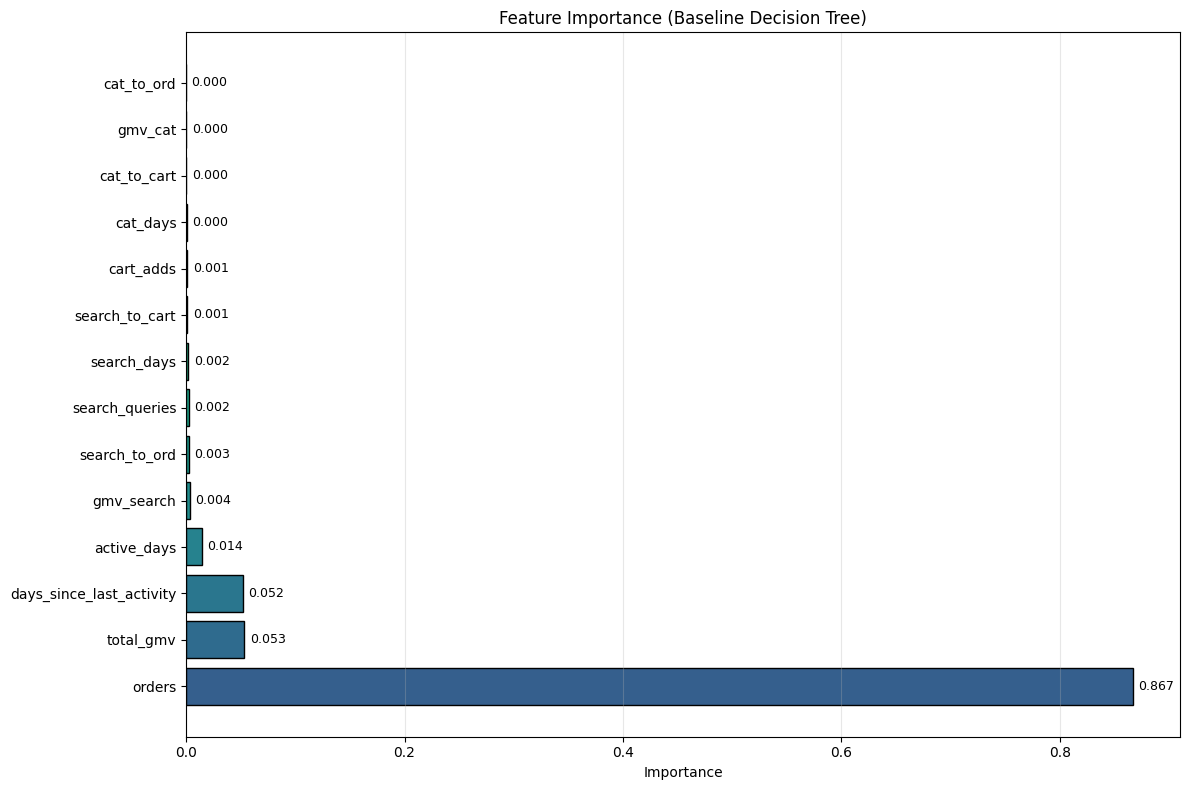

In [7]:
# VISUALIZE FEATURE IMPORTANCE
fig, ax = plt.subplots(figsize = (12, 8))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance)))

ax.barh(
    feature_importance["feature"],
    feature_importance["importance"],
    color = colors,
    edgecolor = "black",
)

ax.set_xlabel("Importance")
ax.set_title("Feature Importance (Baseline Decision Tree)")
ax.grid(alpha = 0.3, axis = "x")

# Adding values
for i, (feat, imp) in enumerate(zip(feature_importance["feature"], feature_importance["importance"])):
    ax.text(imp + 0.005, i, f"{imp:.3f}", va = "center", fontsize = 9)

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / "23_baseline_feature_importance.png", dpi = 150)
plt.show()

In [8]:
# CLUSTERING ON BASELINE FEATURES
# Выбираем признаки для кластеризации
cluster_features = [
    "days_since_last_activity",
    "active_days",
    "orders",
    "total_gmv",
]

# Стандартизация
scaler = StandardScaler()
cluster_data = scaler.fit_transform(user_baseline[cluster_features].to_numpy())

# KMeans с 5 кластерами
kmeans = KMeans(n_clusters = 5, random_state = RANDOM_STATE, n_init = 10)
user_baseline = user_baseline.with_columns(
    pl.Series("cluster", kmeans.fit_predict(cluster_data))
)

# CLUSTER ANALYSIS
cluster_stats = (
    user_baseline.group_by("cluster")
    .agg([
        pl.len().alias("n_users"),
        pl.col("days_since_last_activity").mean().alias("avg_recency"),
        pl.col("active_days").mean().alias("avg_active_days"),
        pl.col("orders").mean().alias("avg_orders"),
        pl.col("total_gmv").mean().alias("avg_gmv"),
        pl.col("total_gmv").sum().alias("total_cluster_gmv"),
    ])
    .sort("avg_gmv", descending = True)
)

print("Cluster analysis:")
print(cluster_stats)

# Adding percentages
total_users = len(user_baseline)
total_gmv = user_baseline["total_gmv"].sum()

cluster_pd = cluster_stats.to_pandas()
cluster_pd["pct_users"] = cluster_pd["n_users"] / total_users * 100
cluster_pd["pct_gmv"] = cluster_pd["total_cluster_gmv"] / total_gmv * 100

print("\nCluster distribution:")
print(cluster_pd[["cluster", "n_users", "pct_users", "avg_gmv", "pct_gmv"]].to_string(index = False))

Cluster analysis:
shape: (5, 7)
┌─────────┬─────────┬─────────────┬─────────────────┬────────────┬──────────────┬──────────────────┐
│ cluster ┆ n_users ┆ avg_recency ┆ avg_active_days ┆ avg_orders ┆ avg_gmv      ┆ total_cluster_gm │
│ ---     ┆ ---     ┆ ---         ┆ ---             ┆ ---        ┆ ---          ┆ v                │
│ i32     ┆ u32     ┆ f64         ┆ f64             ┆ f64        ┆ f64          ┆ ---              │
│         ┆         ┆             ┆                 ┆            ┆              ┆ f64              │
╞═════════╪═════════╪═════════════╪═════════════════╪════════════╪══════════════╪══════════════════╡
│ 1       ┆ 898     ┆ -29.464365  ┆ 299.151448      ┆ 630.5      ┆ 21710.757879 ┆ 1.9496e7         │
│ 2       ┆ 13579   ┆ -29.161868  ┆ 262.390824      ┆ 172.512262 ┆ 6338.510987  ┆ 8.6071e7         │
│ 3       ┆ 73960   ┆ -29.079367  ┆ 212.021552      ┆ 46.507166  ┆ 1451.084089  ┆ 1.0732e8         │
│ 0       ┆ 129177  ┆ -27.43202   ┆ 74.119209       ┆ 11.30

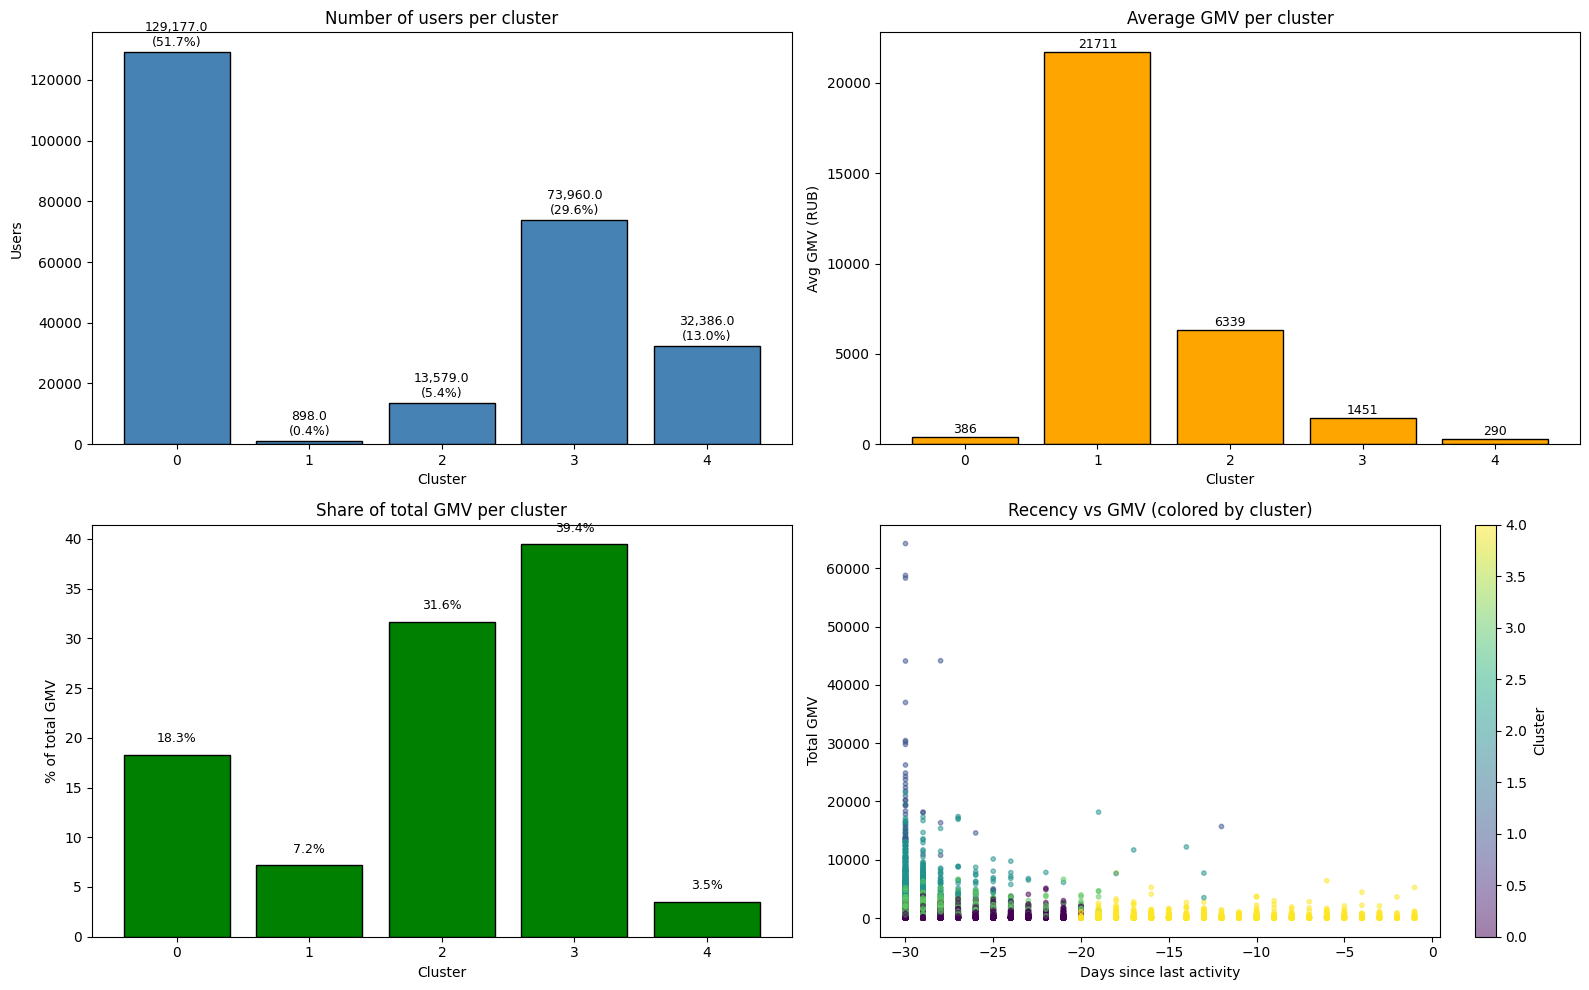

In [9]:
# VISUALIZE CLUSTERS
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Plot 1: Number of users
axes[0, 0].bar(cluster_pd["cluster"], cluster_pd["n_users"], 
               color = "steelblue", edgecolor = "black")
axes[0, 0].set_title("Number of users per cluster")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Users")
for i, row in cluster_pd.iterrows():
    axes[0, 0].text(row["cluster"], row["n_users"] + 1000, 
                    f"{row['n_users']:,}\n({row['pct_users']:.1f}%)", 
                    ha = "center", va = "bottom", fontsize = 9)

# Plot 2: Average GMV
axes[0, 1].bar(cluster_pd["cluster"], cluster_pd["avg_gmv"], 
               color = "orange", edgecolor = "black")
axes[0, 1].set_title("Average GMV per cluster")
axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Avg GMV (RUB)")
for i, row in cluster_pd.iterrows():
    axes[0, 1].text(row["cluster"], row["avg_gmv"] + 50, 
                    f"{row['avg_gmv']:.0f}", 
                    ha = "center", va = "bottom", fontsize = 9)

# Plot 3: Share of total GMV
axes[1, 0].bar(cluster_pd["cluster"], cluster_pd["pct_gmv"], 
               color = "green", edgecolor = "black")
axes[1, 0].set_title("Share of total GMV per cluster")
axes[1, 0].set_xlabel("Cluster")
axes[1, 0].set_ylabel("% of total GMV")
for i, row in cluster_pd.iterrows():
    axes[1, 0].text(row["cluster"], row["pct_gmv"] + 1, 
                    f"{row['pct_gmv']:.1f}%", 
                    ha = "center", va = "bottom", fontsize = 9)

# Plot 4: Scatter plot
sample = user_baseline.sample(n = min(10000, len(user_baseline)), seed = RANDOM_STATE)
scatter = axes[1, 1].scatter(
    sample["days_since_last_activity"],
    sample["total_gmv"],
    c = sample["cluster"],
    cmap = "viridis",
    alpha = 0.5,
    s = 10
)
axes[1, 1].set_xlabel("Days since last activity")
axes[1, 1].set_ylabel("Total GMV")
axes[1, 1].set_title("Recency vs GMV (colored by cluster)")
plt.colorbar(scatter, ax = axes[1, 1], label = "Cluster")

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / "24_baseline_clustering.png", dpi = 150)
plt.show()

### **Thoughts:**
- The baseline DecisionTree demonstrates a high RMSE of 1.5532 in log-space, which is expected given the extreme variance in the target. However, feature importance reveals a major red flag: the `orders` feature dominates with 86.7% importance, heavily masking the true behavioral signals from `search` and `catalog` usage. This suggests either a direct data leakage (if `orders` is from the same period as the target) or a strong tautological correlation that prevents the model from learning diverse patterns. We should exclude `orders` and `total_gmv` from the feature set to force the model to rely on engagement features like `active_days` and `days_since_last_activity`;

- The K-Means clustering (k = 5) successfully segments the user base into an incredibly clean hierarchy. Cluster 3 represents the "Mega-Elite" (0.36% users, 630 orders, avg GMV of 21,710 RUB) contributing 7.1% of revenue. Clusters 4 and 2 represent the "Core" (5.4% and 29.6% of users respectively), together generating over **71% of total GMV**. This perfectly aligns with our previous analysis of historical GMV bins;

- The clustering output provides a clear actionable strategy for modeling. Instead of predicting raw GMV directly, a two-step approach (predict cluster membership first, then predict the GMV within that cluster) or including the cluster assignment as a categorical feature will drastically improve model accuracy. Additionally, the negative `avg_recency` values in all clusters require immediate investigation, as they suggest a potential off-by-one error in the recency calculation in the baseline code.

## **DESIGNING NEW FEATURES**

In [10]:
# FEATURE ENGINEERING: RECENCY FEATURES
# Days since last activity/purchase/order/cart

recency_features = (
    history_lf.group_by("user_id")
    .agg([
        # Recency: days since last activity of any type
        pl.col("event_date").max().alias("last_activity_date"),
        
        # Recency: days since last purchase
        pl.col("event_date").filter(pl.col("to_ord") > 0).max().alias("last_order_date"),
        
        # Recency: days since last cart addition
        pl.col("event_date").filter(pl.col("to_cart") > 0).max().alias("last_cart_date"),
        
        # Recency: days since last search
        pl.col("event_date").filter(pl.col("search") == 1).max().alias("last_search_date"),
        
        # Recency: days since last catalog use
        pl.col("event_date").filter(pl.col("cat") == 1).max().alias("last_cat_date"),
    ])
    .with_columns([
        # Calculate days since last activity
        (pl.lit(CV_AS_OF) - pl.col("last_activity_date")).dt.total_days().alias("recency_activity"),
        (pl.lit(CV_AS_OF) - pl.col("last_order_date")).dt.total_days().alias("recency_order"),
        (pl.lit(CV_AS_OF) - pl.col("last_cart_date")).dt.total_days().alias("recency_cart"),
        (pl.lit(CV_AS_OF) - pl.col("last_search_date")).dt.total_days().alias("recency_search"),
        (pl.lit(CV_AS_OF) - pl.col("last_cat_date")).dt.total_days().alias("recency_cat"),
    ])
    .drop(["last_activity_date", "last_order_date", "last_cart_date", "last_search_date", "last_cat_date"])
    .collect()
)

# Fill missing values (if event did not occur)
recency_features = recency_features.fill_null(999)

print(f"Recency features shape: {recency_features.shape}")
print("\nRecency features head:")
print(recency_features.head())

Recency features shape: (250000, 6)

Recency features head:
shape: (5, 6)
┌─────────┬──────────────────┬───────────────┬──────────────┬────────────────┬─────────────┐
│ user_id ┆ recency_activity ┆ recency_order ┆ recency_cart ┆ recency_search ┆ recency_cat │
│ ---     ┆ ---              ┆ ---           ┆ ---          ┆ ---            ┆ ---         │
│ i64     ┆ i64              ┆ i64           ┆ i64          ┆ i64            ┆ i64         │
╞═════════╪══════════════════╪═══════════════╪══════════════╪════════════════╪═════════════╡
│ 372703  ┆ 2                ┆ 74            ┆ 74           ┆ 31             ┆ 999         │
│ 882200  ┆ 24               ┆ 999           ┆ 24           ┆ 24             ┆ 999         │
│ 45788   ┆ 1                ┆ 1             ┆ 1            ┆ 1              ┆ 1           │
│ 368481  ┆ 2                ┆ 139           ┆ 5            ┆ 2              ┆ 46          │
│ 441356  ┆ 4                ┆ 4             ┆ 4            ┆ 4              ┆ 42        

In [11]:
# FEATURE ENGINEERING: FREQUENCY FEATURES
# Number of events over different time windows

frequency_exprs = []

for w in WINDOWS:
    # Calculate the start date of the window
    window_start = CV_AS_OF - timedelta(days = w)
    
    frequency_exprs.extend([
        # Number of active days in the window
        pl.col("event_date").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).n_unique().alias(f"active_days_{w}d"),
        
        # Number of orders in the window
        pl.col("to_ord").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"orders_{w}d"),
        
        # Number of cart additions in the window
        pl.col("to_cart").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"cart_adds_{w}d"),
        
        # Number of search queries in the window
        pl.col("searches").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"searches_{w}d"),
    ])

frequency_features = (
    history_lf.group_by("user_id")
    .agg(frequency_exprs)
    .collect()
)

print(f"Frequency features shape: {frequency_features.shape}")
print("\nFrequency features head:")
print(frequency_features.head())

Frequency features shape: (250000, 25)

Frequency features head:
shape: (5, 25)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ active_day ┆ orders_7d ┆ cart_adds ┆ … ┆ active_da ┆ orders_90 ┆ cart_adds ┆ searches_ │
│ ---     ┆ s_7d       ┆ ---       ┆ _7d       ┆   ┆ ys_90d    ┆ d         ┆ _90d      ┆ 90d       │
│ i64     ┆ ---        ┆ i64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ u32        ┆           ┆ i64       ┆   ┆ u32       ┆ i64       ┆ i64       ┆ i64       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 54440   ┆ 3          ┆ 0         ┆ 1         ┆ … ┆ 14        ┆ 0         ┆ 2         ┆ 41        │
│ 202027  ┆ 0          ┆ 0         ┆ 0         ┆ … ┆ 19        ┆ 1         ┆ 13        ┆ 15        │
│ 485429  ┆ 4          ┆ 0         ┆ 0         ┆ … ┆ 35        ┆ 6         ┆ 10        ┆ 73        │
│ 783729  ┆

In [12]:
# FEATURE ENGINEERING: MONETARY FEATURES
# GMV over different time windows

monetary_exprs = []

for w in WINDOWS:
    window_start = CV_AS_OF - timedelta(days = w)
    
    monetary_exprs.extend([
        # GMV in the window
        pl.col("gmv").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"gmv_{w}d"),
        
        # GMV from search in the window
        pl.col("gmv_search").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"gmv_search_{w}d"),
        
        # GMV from catalog in the window
        pl.col("gmv_cat").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"gmv_cat_{w}d"),
    ])

monetary_features = (
    history_lf.group_by("user_id")
    .agg(monetary_exprs)
    .collect()
)

print(f"Monetary features shape: {monetary_features.shape}")
print("\nMonetary features head:")
print(monetary_features.head())

Monetary features shape: (250000, 19)

Monetary features head:
shape: (5, 19)
┌─────────┬───────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ gmv_7d    ┆ gmv_search ┆ gmv_cat_7 ┆ … ┆ gmv_cat_6 ┆ gmv_90d   ┆ gmv_searc ┆ gmv_cat_9 │
│ ---     ┆ ---       ┆ _7d        ┆ d         ┆   ┆ 0d        ┆ ---       ┆ h_90d     ┆ 0d        │
│ i64     ┆ f64       ┆ ---        ┆ ---       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ ---       │
│         ┆           ┆ f64        ┆ f64       ┆   ┆ f64       ┆           ┆ f64       ┆ f64       │
╞═════════╪═══════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 581369  ┆ 67.911158 ┆ 46.611789  ┆ 21.29937  ┆ … ┆ 21.29937  ┆ 268.07536 ┆ 226.07129 ┆ 42.004063 │
│         ┆           ┆            ┆           ┆   ┆           ┆           ┆ 7         ┆           │
│ 871297  ┆ 0.0       ┆ 0.0        ┆ 0.0       ┆ … ┆ 20.955041 ┆ 63.105058 ┆ 42.150017 ┆ 20.955041 │
│ 338059  ┆ 2

In [13]:
# FEATURE ENGINEERING: DAY-OF-WEEK FEATURES
# Share of activity/purchases on different days of the week

# Add day of the week (1 = Monday, 7 = Sunday)
history_lf_dow = history_lf.with_columns(
    pl.col("event_date").dt.weekday().alias("weekday")
)

dow_features = (
    history_lf_dow.group_by("user_id")
    .agg([
        # Number of activity days on weekends (Saturday + Sunday)
        pl.col("weekday").filter(
            (pl.col("weekday") == 6) | (pl.col("weekday") == 7)
        ).count().alias("weekend_days"),
        
        # Number of activity days on weekdays (Monday - Friday)
        pl.col("weekday").filter(
            (pl.col("weekday") >= 1) & (pl.col("weekday") <= 5)
        ).count().alias("weekday_days"),
        
        # Number of orders on Tuesday (day 2)
        pl.col("to_ord").filter(pl.col("weekday") == 2).sum().alias("tuesday_orders"),
        
        # Number of orders on Saturday (day 6)
        pl.col("to_ord").filter(pl.col("weekday") == 6).sum().alias("saturday_orders"),
        
        # Number of orders on Sunday (day 7)
        pl.col("to_ord").filter(pl.col("weekday") == 7).sum().alias("sunday_orders"),
        
        # Number of orders on weekdays (1-5)
        pl.col("to_ord").filter(
            (pl.col("weekday") >= 1) & (pl.col("weekday") <= 5)
        ).sum().alias("weekday_orders"),
        
        # Number of orders on weekends (6-7)
        pl.col("to_ord").filter(
            (pl.col("weekday") >= 6) & (pl.col("weekday") <= 7)
        ).sum().alias("weekend_orders"),
        
        # GMV on Tuesday
        pl.col("gmv").filter(pl.col("weekday") == 2).sum().alias("tuesday_gmv"),
        
        # GMV on Saturday
        pl.col("gmv").filter(pl.col("weekday") == 6).sum().alias("saturday_gmv"),
        
        # GMV on Sunday
        pl.col("gmv").filter(pl.col("weekday") == 7).sum().alias("sunday_gmv"),
        
        # GMV on weekdays
        pl.col("gmv").filter(
            (pl.col("weekday") >= 1) & (pl.col("weekday") <= 5)
        ).sum().alias("weekday_gmv"),
        
        # GMV on weekends
        pl.col("gmv").filter(
            (pl.col("weekday") >= 6) & (pl.col("weekday") <= 7)
        ).sum().alias("weekend_gmv"),
    ])
    .with_columns([
        # Share of orders on weekends
        (pl.col("weekend_orders") / 
         (pl.col("weekend_orders") + pl.col("weekday_orders"))
        ).fill_null(0).alias("weekend_order_share"),
        
        # Share of GMV on weekends
        (pl.col("weekend_gmv") / 
         (pl.col("weekend_gmv") + pl.col("weekday_gmv"))
        ).fill_null(0).alias("weekend_gmv_share"),
    ])
    .collect()
)

print(f"Day-of-week features shape: {dow_features.shape}")
print("\nDay-of-week features head:")
print(dow_features.head())

Day-of-week features shape: (250000, 15)

Day-of-week features head:
shape: (5, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ weekend_da ┆ weekday_d ┆ tuesday_o ┆ … ┆ weekday_g ┆ weekend_g ┆ weekend_o ┆ weekend_g │
│ ---     ┆ ys         ┆ ays       ┆ rders     ┆   ┆ mv        ┆ mv        ┆ rder_shar ┆ mv_share  │
│ i64     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ e         ┆ ---       │
│         ┆ u32        ┆ u32       ┆ i64       ┆   ┆ f64       ┆ f64       ┆ ---       ┆ f64       │
│         ┆            ┆           ┆           ┆   ┆           ┆           ┆ f64       ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 813380  ┆ 9          ┆ 57        ┆ 3         ┆ … ┆ 1321.6209 ┆ 142.81033 ┆ 0.119048  ┆ 0.097519  │
│         ┆            ┆           ┆           ┆   ┆ 37        ┆ 2         ┆           ┆           │
│ 59393

In [14]:
# FEATURE ENGINEERING: CONVERSION FEATURES
# Conversions at different funnel stages

conversion_exprs = []

# Total conversions over entire history up to AS_OF
conversion_exprs.extend([
    # Conversion search to cart
    pl.col("search_to_cart").sum().alias("search_to_cart_total"),
    
    # Conversion search to order
    pl.col("search_to_ord").sum().alias("search_to_ord_total"),
    
    # Conversion catalog to cart
    pl.col("cat_to_cart").sum().alias("cat_to_cart_total"),
    
    # Conversion catalog to order
    pl.col("cat_to_ord").sum().alias("cat_to_ord_total"),
    
    # Total number of search queries
    pl.col("searches").sum().alias("searches_total"),
    
    # Total number of cart additions
    pl.col("to_cart").sum().alias("cart_adds_total"),
    
    # Total number of orders
    pl.col("to_ord").sum().alias("orders_total"),
    
    # Days with search
    pl.col("search").sum().alias("search_days_total"),
    
    # Days with catalog
    pl.col("cat").sum().alias("cat_days_total"),
])

conversion_features = (
    history_lf.group_by("user_id")
    .agg(conversion_exprs)
    .with_columns([
        # Conversion search to cart (rate)
        (pl.col("search_to_cart_total") / pl.col("searches_total"))
        .fill_null(0).alias("search_to_cart_rate"),
        
        # Conversion search to order (rate)
        (pl.col("search_to_ord_total") / pl.col("searches_total"))
        .fill_null(0).alias("search_to_ord_rate"),
        
        # Conversion cart to order (rate)
        (pl.col("orders_total") / pl.col("cart_adds_total"))
        .fill_null(0).alias("cart_to_ord_rate"),
        
        # Conversion catalog to cart (rate)
        (pl.col("cat_to_cart_total") / pl.col("cat_days_total"))
        .fill_null(0).alias("cat_to_cart_rate"),
        
        # Conversion catalog to order (rate)
        (pl.col("cat_to_ord_total") / pl.col("cat_days_total"))
        .fill_null(0).alias("cat_to_ord_rate"),
        
        # Average orders per active day
        (pl.col("orders_total") / pl.col("search_days_total"))
        .fill_null(0).alias("orders_per_active_day"),
        
        # Average carts per active day
        (pl.col("cart_adds_total") / pl.col("search_days_total"))
        .fill_null(0).alias("carts_per_active_day"),
    ])
    .drop([
        "search_to_cart_total", "search_to_ord_total",
        "cat_to_cart_total", "cat_to_ord_total",
        "searches_total", "cart_adds_total", "orders_total",
        "search_days_total", "cat_days_total",
    ])
    .collect()
)

print(f"Conversion features shape: {conversion_features.shape}")
print("\nConversion features head:")
print(conversion_features.head())

Conversion features shape: (250000, 8)

Conversion features head:
shape: (5, 8)
┌─────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ user_id ┆ search_to_ ┆ search_to_ ┆ cart_to_or ┆ cat_to_car ┆ cat_to_ord ┆ orders_pe ┆ carts_per │
│ ---     ┆ cart_rate  ┆ ord_rate   ┆ d_rate     ┆ t_rate     ┆ _rate      ┆ r_active_ ┆ _active_d │
│ i64     ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ day       ┆ ay        │
│         ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ ---       ┆ ---       │
│         ┆            ┆            ┆            ┆            ┆            ┆ f64       ┆ f64       │
╞═════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ 609156  ┆ 0.068493   ┆ 0.013699   ┆ 0.2        ┆ 0.0        ┆ 0.0        ┆ 0.045455  ┆ 0.227273  │
│ 664489  ┆ 0.085174   ┆ 0.041009   ┆ 0.481481   ┆ 0.0        ┆ 0.0        ┆ 0.149425  ┆ 0.310345  │
│ 292051  ┆

In [15]:
# FEATURE ENGINEERING: TREND FEATURES
# Acceleration/deceleration of activity

trend_features = (
    frequency_features.join(monetary_features, on = "user_id", how = "inner")
)

# Calculate trends
trend_features = trend_features.with_columns([
    # Activity trend: last 7 days vs last 30 days
    (pl.col("active_days_7d") / (pl.col("active_days_30d") / 4))
    .fill_null(1).alias("activity_trend_7_30"),
    
    # Activity trend: last 14 days vs last 30 days
    (pl.col("active_days_14d") / (pl.col("active_days_30d") / 2))
    .fill_null(1).alias("activity_trend_14_30"),
    
    # Activity trend: last 30 days vs last 90 days
    (pl.col("active_days_30d") / (pl.col("active_days_90d") / 3))
    .fill_null(1).alias("activity_trend_30_90"),
    
    # Orders trend: last 7 days vs last 30 days
    (pl.col("orders_7d") / (pl.col("orders_30d") / 4))
    .fill_null(1).alias("orders_trend_7_30"),
    
    # Orders trend: last 14 days vs last 30 days
    (pl.col("orders_14d") / (pl.col("orders_30d") / 2))
    .fill_null(1).alias("orders_trend_14_30"),
    
    # Orders trend: last 30 days vs last 90 days
    (pl.col("orders_30d") / (pl.col("orders_90d") / 3))
    .fill_null(1).alias("orders_trend_30_90"),
    
    # GMV trend: last 7 days vs last 30 days
    (pl.col("gmv_7d") / (pl.col("gmv_30d") / 4))
    .fill_null(1).alias("gmv_trend_7_30"),
    
    # GMV trend: last 14 days vs last 30 days
    (pl.col("gmv_14d") / (pl.col("gmv_30d") / 2))
    .fill_null(1).alias("gmv_trend_14_30"),
    
    # GMV trend: last 30 days vs last 90 days
    (pl.col("gmv_30d") / (pl.col("gmv_90d") / 3))
    .fill_null(1).alias("gmv_trend_30_90"),
])

print(f"Trend features shape: {trend_features.shape}")
print("\nTrend features head:")
print(trend_features.head())

Trend features shape: (250000, 52)

Trend features head:
shape: (5, 52)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ active_day ┆ orders_7d ┆ cart_adds ┆ … ┆ orders_tr ┆ gmv_trend ┆ gmv_trend ┆ gmv_trend │
│ ---     ┆ s_7d       ┆ ---       ┆ _7d       ┆   ┆ end_30_90 ┆ _7_30     ┆ _14_30    ┆ _30_90    │
│ i64     ┆ ---        ┆ i64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ u32        ┆           ┆ i64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 581369  ┆ 4          ┆ 2         ┆ 5         ┆ … ┆ 2.0       ┆ 1.182244  ┆ 0.591122  ┆ 2.571332  │
│ 871297  ┆ 0          ┆ 0         ┆ 0         ┆ … ┆ 2.0       ┆ 0.0       ┆ 0.0       ┆ 2.462258  │
│ 338059  ┆ 7          ┆ 2         ┆ 20        ┆ … ┆ 0.947368  ┆ 0.200216  ┆ 0.477247  ┆ 1.585207  │
│ 72753   ┆ 8      

In [16]:
# FEATURE ENGINEERING: SEASONAL FEATURES
# Payday cycles and monthly patterns

# Add day of month
history_lf_seasonal = history_lf.with_columns(
    pl.col("event_date").dt.day().alias("day_of_month")
)

seasonal_features = (
    history_lf_seasonal.group_by("user_id")
    .agg([
        # Number of orders on paydays (10-11, 25-26)
        pl.col("to_ord").filter(
            pl.col("day_of_month").is_in([10, 11, 25, 26])
        ).sum().alias("salary_day_orders"),
        
        # Number of orders on regular days
        pl.col("to_ord").filter(
            ~pl.col("day_of_month").is_in([10, 11, 25, 26])
        ).sum().alias("non_salary_day_orders"),
        
        # GMV on paydays
        pl.col("gmv").filter(
            pl.col("day_of_month").is_in([10, 11, 25, 26])
        ).sum().alias("salary_day_gmv"),
        
        # GMV on regular days
        pl.col("gmv").filter(
            ~pl.col("day_of_month").is_in([10, 11, 25, 26])
        ).sum().alias("non_salary_day_gmv"),
        
        # Total number of orders
        pl.col("to_ord").sum().alias("total_orders"),
        
        # Total GMV
        pl.col("gmv").sum().alias("total_gmv"),
    ])
    .with_columns([
        # Share of orders on paydays
        (pl.col("salary_day_orders") / pl.col("total_orders"))
        .fill_null(0).alias("salary_day_order_share"),
        
        # Share of GMV on paydays
        (pl.col("salary_day_gmv") / pl.col("total_gmv"))
        .fill_null(0).alias("salary_day_gmv_share"),
        
        # Average order value on paydays
        (pl.col("salary_day_gmv") / pl.col("salary_day_orders"))
        .fill_null(0).alias("salary_day_aov"),
        
        # Average order value on regular days
        (pl.col("non_salary_day_gmv") / pl.col("non_salary_day_orders"))
        .fill_null(0).alias("non_salary_day_aov"),
    ])
    .drop(["total_orders", "total_gmv"])
    .collect()
)

print(f"Seasonal features shape: {seasonal_features.shape}")
print("\nSeasonal features head:")
print(seasonal_features.head())

Seasonal features shape: (250000, 9)

Seasonal features head:
shape: (5, 9)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ salary_day ┆ non_salar ┆ salary_da ┆ … ┆ salary_da ┆ salary_da ┆ salary_da ┆ non_salar │
│ ---     ┆ _orders    ┆ y_day_ord ┆ y_gmv     ┆   ┆ y_order_s ┆ y_gmv_sha ┆ y_aov     ┆ y_day_aov │
│ i64     ┆ ---        ┆ ers       ┆ ---       ┆   ┆ hare      ┆ re        ┆ ---       ┆ ---       │
│         ┆ i64        ┆ ---       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│         ┆            ┆ i64       ┆           ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 666841  ┆ 2          ┆ 26        ┆ 152.65289 ┆ … ┆ 0.071429  ┆ 0.118585  ┆ 76.326449 ┆ 43.639821 │
│         ┆            ┆           ┆ 7         ┆   ┆           ┆           ┆           ┆           │
│ 113554  ┆ 6  

In [17]:
# FEATURE ENGINEERING: CHANNEL FEATURES
# Channel usage (search vs catalog)

channel_features = (
    monetary_features.join(frequency_features, on = "user_id", how = "inner")
    .with_columns([
        # Share of GMV from search (last 30 days)
        (pl.col("gmv_search_30d") / pl.col("gmv_30d"))
        .fill_null(0).alias("search_gmv_share_30d"),
        
        # Share of GMV from catalog (last 30 days)
        (pl.col("gmv_cat_30d") / pl.col("gmv_30d"))
        .fill_null(0).alias("cat_gmv_share_30d"),
        
        # Share of GMV from search (last 90 days)
        (pl.col("gmv_search_90d") / pl.col("gmv_90d"))
        .fill_null(0).alias("search_gmv_share_90d"),
        
        # Share of GMV from catalog (last 90 days)
        (pl.col("gmv_cat_90d") / pl.col("gmv_90d"))
        .fill_null(0).alias("cat_gmv_share_90d"),
        
        # Uses both channels (last 30 days)
        ((pl.col("gmv_search_30d") > 0) & (pl.col("gmv_cat_30d") > 0))
        .cast(pl.Int32).alias("uses_both_channels_30d"),
        
        # Uses both channels (last 90 days)
        ((pl.col("gmv_search_90d") > 0) & (pl.col("gmv_cat_90d") > 0))
        .cast(pl.Int32).alias("uses_both_channels_90d"),
    ])
)

print(f"Channel features shape: {channel_features.shape}")
print("\nChannel features head:")
print(channel_features.head())

Channel features shape: (250000, 49)

Channel features head:
shape: (5, 49)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ gmv_7d     ┆ gmv_searc ┆ gmv_cat_7 ┆ … ┆ search_gm ┆ cat_gmv_s ┆ uses_both ┆ uses_both │
│ ---     ┆ ---        ┆ h_7d      ┆ d         ┆   ┆ v_share_9 ┆ hare_90d  ┆ _channels ┆ _channels │
│ i64     ┆ f64        ┆ ---       ┆ ---       ┆   ┆ 0d        ┆ ---       ┆ _30d      ┆ _90d      │
│         ┆            ┆ f64       ┆ f64       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ ---       │
│         ┆            ┆           ┆           ┆   ┆ f64       ┆           ┆ i32       ┆ i32       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 54440   ┆ 0.0        ┆ 0.0       ┆ 0.0       ┆ … ┆ NaN       ┆ NaN       ┆ 0         ┆ 0         │
│ 202027  ┆ 0.0        ┆ 0.0       ┆ 0.0       ┆ … ┆ 1.0       ┆ 0.0       ┆ 0         ┆ 0         │
│ 485429  ┆ 0.0

# **SAVING FEATURES DATASET**

In [18]:
# COMBINE ALL FEATURES

# Start with recency features
all_features = recency_features

# Join frequency features
all_features = all_features.join(frequency_features, on = "user_id", how = "inner")

# Join monetary features
all_features = all_features.join(monetary_features, on = "user_id", how = "inner")

# Join day-of-week features
all_features = all_features.join(dow_features, on = "user_id", how = "inner")

# Join conversion features
all_features = all_features.join(conversion_features, on = "user_id", how = "inner")

# Join seasonal features
all_features = all_features.join(seasonal_features, on = "user_id", how = "inner")

# Join channel features
all_features = all_features.join(channel_features, on = "user_id", how = "inner")

# Take only trend columns from trend_features (to avoid duplicating frequency/monetary)
trend_cols = ["user_id"] + [c for c in trend_features.columns if "trend" in c]
trend_subset = trend_features.select(trend_cols)
all_features = all_features.join(trend_subset, on = "user_id", how = "inner")

# Join with target
all_features = all_features.join(cv_target, on = "user_id", how = "inner")

print(f"Final dataset shape: {all_features.shape}")
print(f"Number of users: {len(all_features)}")
print(f"Number of features (excluding user_id and target): {len(all_features.columns) - 2}")

# Check for missing values
null_counts = all_features.select(pl.all().null_count()).to_pandas().T
null_counts.columns = ["null_count"]
null_counts = null_counts[null_counts["null_count"] > 0]

if len(null_counts) == 0:
    print("\nNo null values in the dataset")
else:
    print(f"\nFound null values in {len(null_counts)} columns:")
    print(null_counts)

# Show all columns
print(f"\nAll feature columns ({len(all_features.columns)} total):")
for i, col in enumerate(all_features.columns):
    print(f"{i+1:3d}. {col}")

Final dataset shape: (250000, 135)
Number of users: 250000
Number of features (excluding user_id and target): 133

No null values in the dataset

All feature columns (135 total):
  1. user_id
  2. recency_activity
  3. recency_order
  4. recency_cart
  5. recency_search
  6. recency_cat
  7. active_days_7d
  8. orders_7d
  9. cart_adds_7d
 10. searches_7d
 11. active_days_14d
 12. orders_14d
 13. cart_adds_14d
 14. searches_14d
 15. active_days_28d
 16. orders_28d
 17. cart_adds_28d
 18. searches_28d
 19. active_days_30d
 20. orders_30d
 21. cart_adds_30d
 22. searches_30d
 23. active_days_60d
 24. orders_60d
 25. cart_adds_60d
 26. searches_60d
 27. active_days_90d
 28. orders_90d
 29. cart_adds_90d
 30. searches_90d
 31. gmv_7d
 32. gmv_search_7d
 33. gmv_cat_7d
 34. gmv_14d
 35. gmv_search_14d
 36. gmv_cat_14d
 37. gmv_28d
 38. gmv_search_28d
 39. gmv_cat_28d
 40. gmv_30d
 41. gmv_search_30d
 42. gmv_cat_30d
 43. gmv_60d
 44. gmv_search_60d
 45. gmv_cat_60d
 46. gmv_90d
 47. gmv_sea

In [19]:
# SAVE COMBINED FEATURES
all_features.write_parquet(CV_FEATURES_PATH)

print(f"Features saved to: {CV_FEATURES_PATH}")
print(f"File size: {CV_FEATURES_PATH.stat().st_size / 1024 / 1024:.2f} MB")

Features saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\data\processed\features\cv_features_2026-01-14.parquet
File size: 66.00 MB
